<a href="https://colab.research.google.com/github/MarceCorreal2/Robots-NT/blob/main/Carga_Limpieza_Grafica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [170]:
# Celda 1 — Importes y configuración

import pandas as pd
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

In [171]:
# Celda 2 — Conectar Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [172]:
# Celda 3 - Buscar archivos en Drive
# Para encontrar archivo sin elaborar la ruta pongo:

import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

/content/drive/MyDrive/Robots/Mis Bots/Datos Backtest/Datos Crudos/RB01_MNQ_A_T001.csv
/content/drive/MyDrive/Robots/Mis Bots/Datos Backtest/Datos Crudos/RB01_MNQ_A_T002.csv
/content/drive/MyDrive/Robots/Mis Bots/Datos Backtest/Datos Limpios/RB01_MNQ_A_T001_limpio.csv


In [173]:
# Celda 4 — Se establecen las variables

bot_name = 'RB01_MNQ_A'
test_number = 'T001' # <--- Modifica este valor para diferentes pruebas (ej. 'T002')
instrument = 'MNQ'

print(f"Bot Name: {bot_name}")
print(f"Test Number: {test_number}")
print(f"Instrument: {instrument}")

Bot Name: RB01_MNQ_A
Test Number: T001
Instrument: MNQ


In [174]:
# Celda 5 — Se generan rutas dinámicas

import os

# 1. Define base path for raw data files
raw_data_base_path = '/content/drive/MyDrive/Robots/Mis Bots/Datos Backtest/Datos Crudos/'

# 2. Define base path for cleaned data files
cleaned_data_base_path = '/content/drive/MyDrive/Robots/Mis Bots/Datos Backtest/Datos Limpios/'


# 3. Define base path for graph output
graph_output_base_path  = '/content/drive/MyDrive/Robots/Mis Bots/Datos Backtest/Graficas Backtest/'


# 4. Construct full file path for raw CSV data
raw_data_file_path = os.path.join(raw_data_base_path, f'{bot_name}_{test_number}.csv')

# 5. Construct full file path for cleaned CSV data
cleaned_data_file_path = os.path.join(cleaned_data_base_path, f'{bot_name}_{test_number}_limpio.csv')

# 6. Construct full directory path for graphs
graph_output_directory = os.path.join(graph_output_base_path, f'{bot_name}_{test_number}')

# 7. Print all generated paths for verification
print(f"Ruta de archivo de datos crudos: {raw_data_file_path}")
print(f"Ruta de archivo de datos limpios: {cleaned_data_file_path}")
print(f"Directorio de salida de gráficas: {graph_output_directory}")

Ruta de archivo de datos crudos: /content/drive/MyDrive/Robots/Mis Bots/Datos Backtest/Datos Crudos/RB01_MNQ_A_T001.csv
Ruta de archivo de datos limpios: /content/drive/MyDrive/Robots/Mis Bots/Datos Backtest/Datos Limpios/RB01_MNQ_A_T001_limpio.csv
Directorio de salida de gráficas: /content/drive/MyDrive/Robots/Mis Bots/Datos Backtest/Graficas Backtest/RB01_MNQ_A_T001


In [175]:
# Celda 6 - Subir datos crudos

# La ruta del archivo se obtiene dinámicamente de la celda de configuración 'a17c76af'.
# Asegúrate de que esa celda haya sido ejecutada para definir 'raw_data_file_path'.
full_file_path = raw_data_file_path

print(f"Cargando archivo: {full_file_path}")

df_raw_copy = pd.read_csv(
    full_file_path,
    sep=';',
    dtype={'Entry time': str, 'Exit time': str}, # Explicitly load as strings
    keep_default_na=False,  # Do not interpret default NA values
    na_values=[]            # Do not interpret any specific values as NA (empty strings become empty strings)
).copy()
df_raw_copy = df_raw_copy.loc[:, ~df_raw_copy.columns.str.contains('Unnamed')].copy()
df = df_raw_copy.copy() # df will still be the main dataframe for operations

print(f"DataFrame cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")
display(df.head())

Cargando archivo: /content/drive/MyDrive/Robots/Mis Bots/Datos Backtest/Datos Crudos/RB01_MNQ_A_T001.csv
DataFrame cargado con 50 filas y 23 columnas.


,Trade number,Instrument,Account,Strategy,Market pos.,Qty,Entry price,Exit price,Entry time,Exit time,Entry name,Exit name,Profit,Cum. net profit,Commission,Clearing Fee,Exchange Fee,IP Fee,NFA Fee,MAE,MFE,ETD,Bars
0,1,MNQ JUN26,Backtest,RB01MNQA,Long,1,"29777,75","29901,00",24/05/2026 6:22:00 p m,25/05/2026 3:20:00 a m,Buy,Sell,"$ 244,60","$ 244,60","$ 1,90","$ 0,00","$ 0,00","$ 0,00","$ 0,00","$ 26,00","$ 434,50","$ 189,90",539
1,2,MNQ JUN26,Backtest,RB01MNQA,Long,1,"29921,00","29931,25",25/05/2026 3:24:00 a m,25/05/2026 10:34:00 a m,Buy,Sell,"$ 18,60","$ 263,20","$ 1,90","$ 0,00","$ 0,00","$ 0,00","$ 0,00","$ 12,00","$ 147,50","$ 128,90",431
2,3,MNQ JUN26,Backtest,RB01MNQA,Long,1,"29938,50","29926,75",25/05/2026 10:55:00 a m,25/05/2026 10:56:00 a m,Buy,Sell,"-$ 25,40","$ 237,80","$ 1,90","$ 0,00","$ 0,00","$ 0,00","$ 0,00","$ 30,50","$ 3,50","$ 28,90",2
3,4,MNQ JUN26,Backtest,RB01MNQA,Long,1,"29959,50","29933,75",25/05/2026 11:12:00 a m,25/05/2026 11:31:00 a m,Buy,Sell,"-$ 53,40","$ 184,40","$ 1,90","$ 0,00","$ 0,00","$ 0,00","$ 0,00","$ 54,50","$ 62,50","$ 115,90",20
4,5,MNQ JUN26,Backtest,RB01MNQA,Long,1,"29938,50","29935,00",25/05/2026 11:36:00 a m,25/05/2026 11:38:00 a m,Buy,Sell,"-$ 8,90","$ 175,50","$ 1,90","$ 0,00","$ 0,00","$ 0,00","$ 0,00","$ 10,50","$ 6,00","$ 14,90",3


In [176]:
# Celda 7 - Limpieza de datos crudos para posterior análisis

import pandas as pd

# Check if df_raw is None before attempting to copy
if 'df_raw' not in locals() or df_raw is None:
    print("ERROR: 'df_raw' DataFrame not loaded. Please ensure the raw data CSV file is correctly loaded in the preceding cells.")
    print("Specifically, check the `raw_data_file_path` in cell 'a17c76af' and confirm the file exists in Google Drive.")
    df = None # Ensure df is also None if df_raw is not available
else:
    df = df_raw.copy()

    # Clean and convert date columns
    df["Entry time"] = df["Entry time"].astype(str).str.replace('\u202a', '', regex=False).str.replace('\u202f', '', regex=False).str.strip().str.replace('a.m', 'AM', regex=False).str.replace('p.m', 'PM', regex=False)
    df["Exit time"] = df["Exit time"].astype(str).str.replace('\u202a', '', regex=False).str.replace('\u202f', '', regex=False).str.strip().str.replace('a.m', 'AM', regex=False).str.replace('p.m', 'PM', regex=False)
    df["Entry time"] = pd.to_datetime(df["Entry time"], format='%d/%m/%Y %I:%M:%S%p', errors='coerce')
    df["Exit time"] = pd.to_datetime(df["Exit time"], format='%d/%m/%Y %I:%M:%S%p', errors='coerce')

    # Clean and convert numerical columns
    cols_numericas = [
        "Entry price", "Exit price", "Profit", "Cum. net profit",
        "Commission", "Clearing Fee", "Exchange Fee", "IP Fee",
        "NFA Fee", "MAE", "MFE", "ETD"
    ]
    for col in cols_numericas:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(' ', '', regex=False)
            .str.replace(',', '.', regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

    print("Date and numerical columns cleaned and converted.")

    print("\nVerifying data types after conversion:")
    df.info()

    print("\nChecking for null values introduced by conversion:")
    print(df.isnull().sum())

    print("\nDisplaying the first few rows of the cleaned DataFrame:")
    display(df.head())


Date and numerical columns cleaned and converted.

Verifying data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Trade number     50 non-null     int64         
 1   Instrument       50 non-null     object        
 2   Account          50 non-null     object        
 3   Strategy         50 non-null     object        
 4   Market pos.      50 non-null     object        
 5   Qty              50 non-null     int64         
 6   Entry price      50 non-null     float64       
 7   Exit price       50 non-null     float64       
 8   Entry time       50 non-null     datetime64[ns]
 9   Exit time        50 non-null     datetime64[ns]
 10  Entry name       50 non-null     object        
 11  Exit name        50 non-null     object        
 12  Profit           50 non-null     float64       
 13  Cum. ne

,Trade number,Instrument,Account,Strategy,Market pos.,Qty,Entry price,Exit price,Entry time,Exit time,Entry name,Exit name,Profit,Cum. net profit,Commission,Clearing Fee,Exchange Fee,IP Fee,NFA Fee,MAE,MFE,ETD,Bars
0,1,MNQ JUN26,Backtest,RB01MNQA,Long,1,29777.75,29901.00,2026-05-24 18:22:00,2026-05-25 03:20:00,Buy,Sell,244.6,244.6,1.9,0.0,0.0,0.0,0.0,26.0,434.5,189.9,539
1,2,MNQ JUN26,Backtest,RB01MNQA,Long,1,29921.00,29931.25,2026-05-25 03:24:00,2026-05-25 10:34:00,Buy,Sell,18.6,263.2,1.9,0.0,0.0,0.0,0.0,12.0,147.5,128.9,431
2,3,MNQ JUN26,Backtest,RB01MNQA,Long,1,29938.50,29926.75,2026-05-25 10:55:00,2026-05-25 10:56:00,Buy,Sell,-25.4,237.8,1.9,0.0,0.0,0.0,0.0,30.5,3.5,28.9,2
3,4,MNQ JUN26,Backtest,RB01MNQA,Long,1,29959.50,29933.75,2026-05-25 11:12:00,2026-05-25 11:31:00,Buy,Sell,-53.4,184.4,1.9,0.0,0.0,0.0,0.0,54.5,62.5,115.9,20
4,5,MNQ JUN26,Backtest,RB01MNQA,Long,1,29938.50,29935.00,2026-05-25 11:36:00,2026-05-25 11:38:00,Buy,Sell,-8.9,175.5,1.9,0.0,0.0,0.0,0.0,10.5,6.0,14.9,3


In [177]:
# Celda 8 - Guardar datos limpios

import os
import pandas as pd

if os.path.exists(cleaned_data_file_path):
    print(f"El archivo de datos limpios se ha guardado correctamente en: {cleaned_data_file_path}")
    try:
        # Optional: Load the file to verify its integrity
        df_verified = pd.read_csv(cleaned_data_file_path, sep=';')
        print(f"Se pudo cargar el archivo verificado con {df_verified.shape[0]} filas y {df_verified.shape[1]} columnas.")
    except Exception as e:
        print(f"Error al intentar cargar el archivo para verificación: {e}")
else:
    print(f"ERROR: El archivo de datos limpios NO se encontró en: {cleaned_data_file_path}")



El archivo de datos limpios se ha guardado correctamente en: /content/drive/MyDrive/Robots/Mis Bots/Datos Backtest/Datos Limpios/RB01_MNQ_A_T001_limpio.csv
Se pudo cargar el archivo verificado con 50 filas y 23 columnas.


Gráfica Equity Curve guardada en: /content/drive/MyDrive/Robots/Mis Bots/Datos Backtest/Graficas Backtest/RB01_MNQ_A_T001/Equity_Curve.jpg


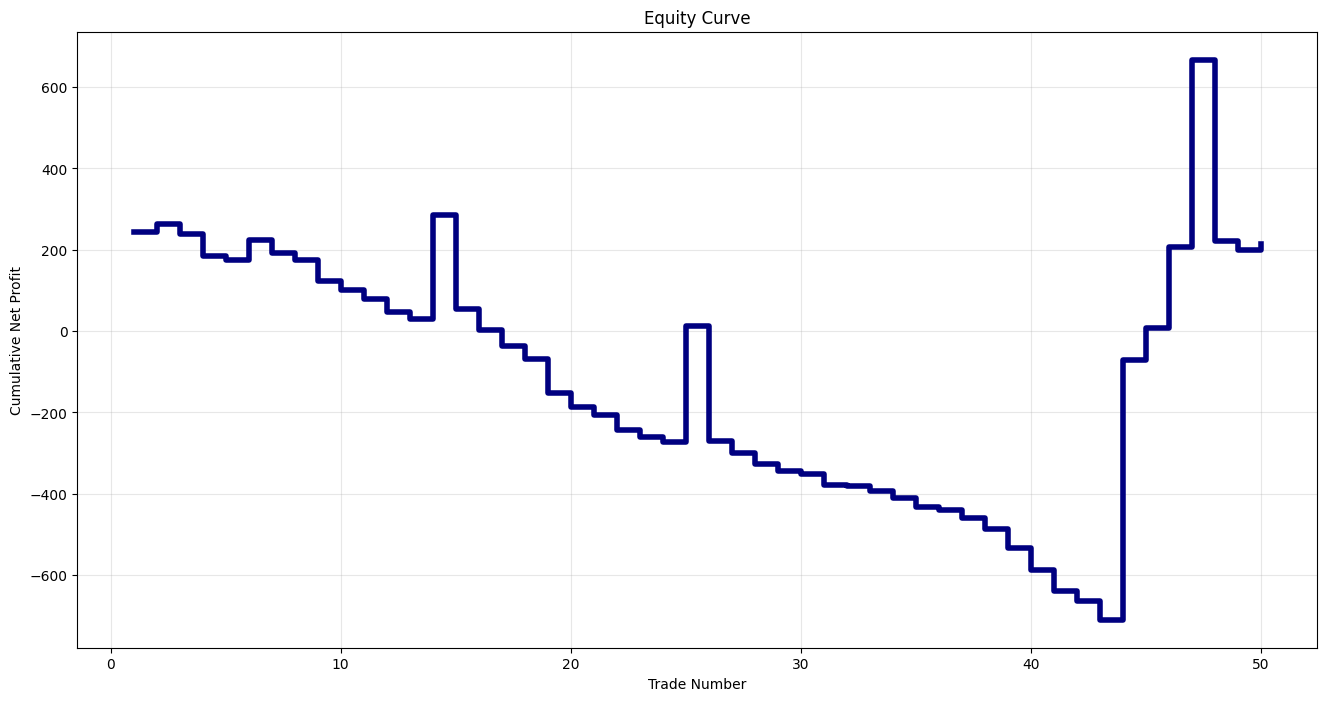

In [178]:
# Celda 9 — Generación de Gráficas (Equity)

import matplotlib.pyplot as plt
import os

os.makedirs(graph_output_directory, exist_ok=True)

plt.figure(figsize=(16,8))

plt.step(
    df['Trade number'],
    df['Cum. net profit'],
    where='post',
    linewidth=4,
    color='navy'
)

plt.title('Equity Curve')
plt.xlabel('Trade Number')
plt.ylabel('Cumulative Net Profit')
plt.grid(True, alpha=0.3)

output_path_equity_curve = os.path.join(graph_output_directory, 'Equity_Curve.jpg')

plt.savefig(output_path_equity_curve, bbox_inches='tight', dpi=300)
print(f'Gráfica Equity Curve guardada en: {output_path_equity_curve}')

plt.show()
plt.close()

Gráfica Equity y Drawdown guardada en: /content/drive/MyDrive/Robots/Mis Bots/Datos Backtest/Graficas Backtest/RB01_MNQ_A_T001/Equity_Drawdown.jpg


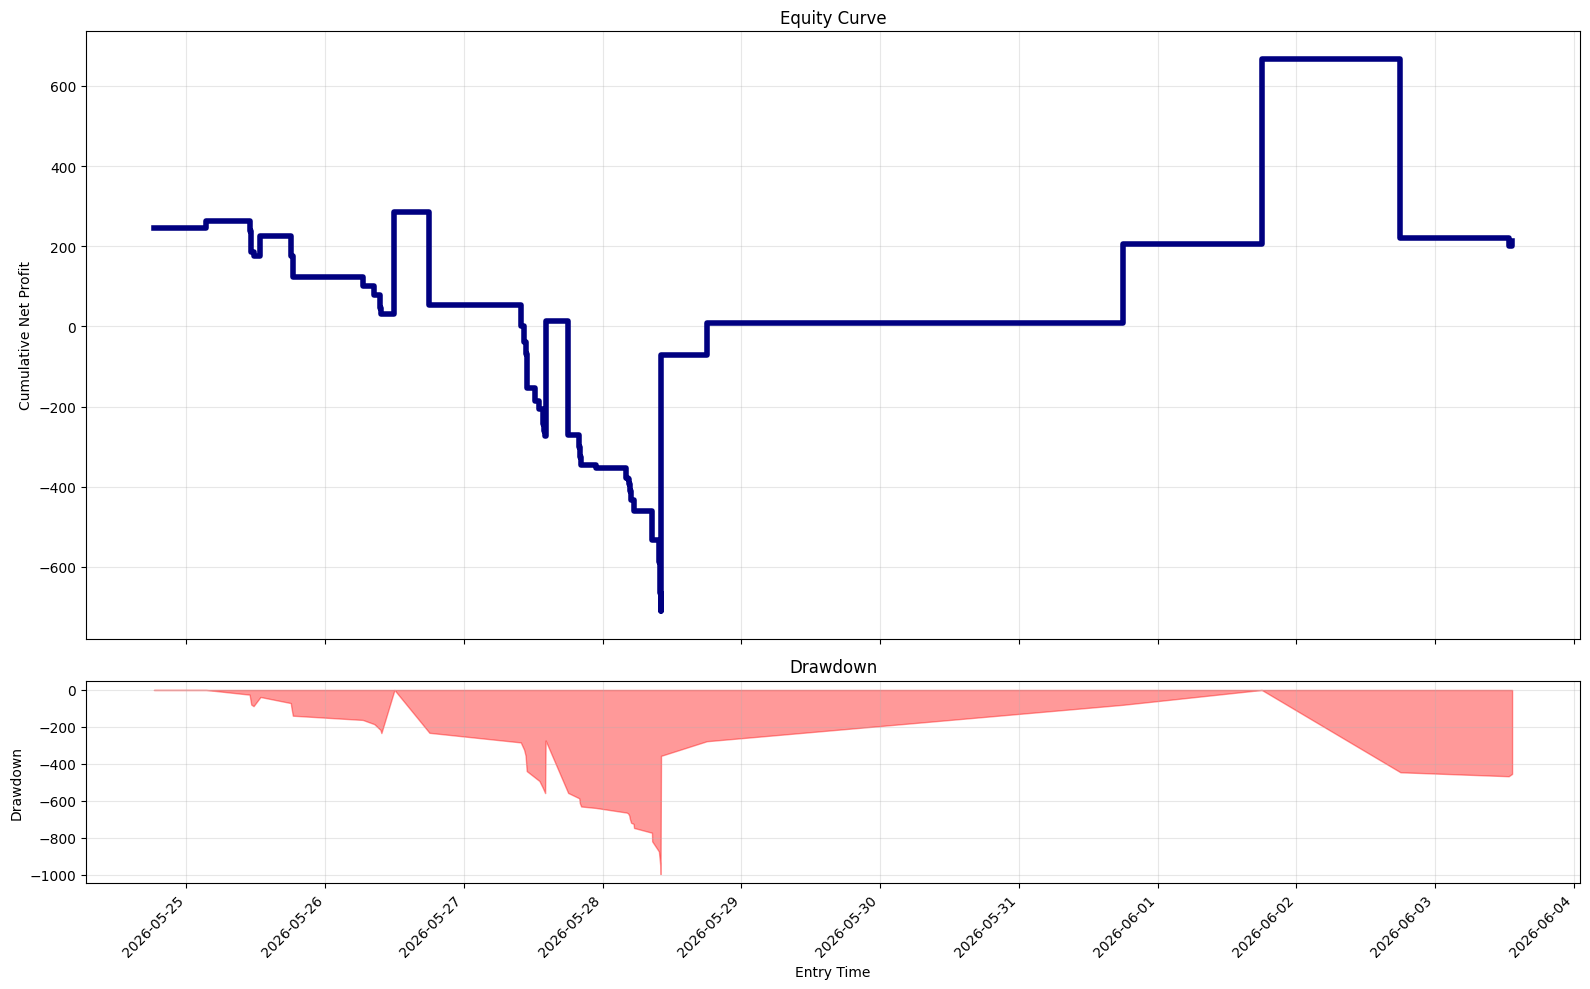

In [179]:
# Celda 10 — Generación de Graficas (Draw Down))

import os
import matplotlib.pyplot as plt

# Calculate HighWaterMark and Drawdown
df['HighWaterMark'] = df['Cum. net profit'].cummax()
df['Drawdown'] = df['Cum. net profit'] - df['HighWaterMark']

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(16,10),
    sharex=True,
    gridspec_kw={'height_ratios':[3,1]}
)

# Plot Equity Curve
ax1.step(
    df['Entry time'],
    df['Cum. net profit'],
    where='post',
    color='navy',
    linewidth=4
)
ax1.set_title('Equity Curve')
ax1.set_ylabel('Cumulative Net Profit')
ax1.grid(alpha=0.3)

# Plot Drawdown
ax2.fill_between(
    df['Entry time'],
    df['Drawdown'],
    0,
    color='red',
    alpha=0.4
)
ax2.set_title('Drawdown')
ax2.set_ylabel('Drawdown')
ax2.grid(alpha=0.3)

# Set common labels and rotate x-axis labels for readability
plt.xlabel('Entry Time')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Construct the full output path for the equity and drawdown graph
output_path_equity_drawdown = os.path.join(graph_output_directory, 'Equity_Drawdown.jpg')

# Create the directory if it doesn't exist
os.makedirs(graph_output_directory, exist_ok=True)

# Save the figure before displaying it
fig.savefig(output_path_equity_drawdown, bbox_inches='tight', dpi=300)
print(f'Gráfica Equity y Drawdown guardada en: {output_path_equity_drawdown}')

plt.show()
plt.close(fig)

Gráfica Ganancia/Pérdida por Trade guardada en: /content/drive/MyDrive/Robots/Mis Bots/Datos Backtest/Graficas Backtest/RB01_MNQ_A_T001/Profit_Loss_Per_Trade.jpg


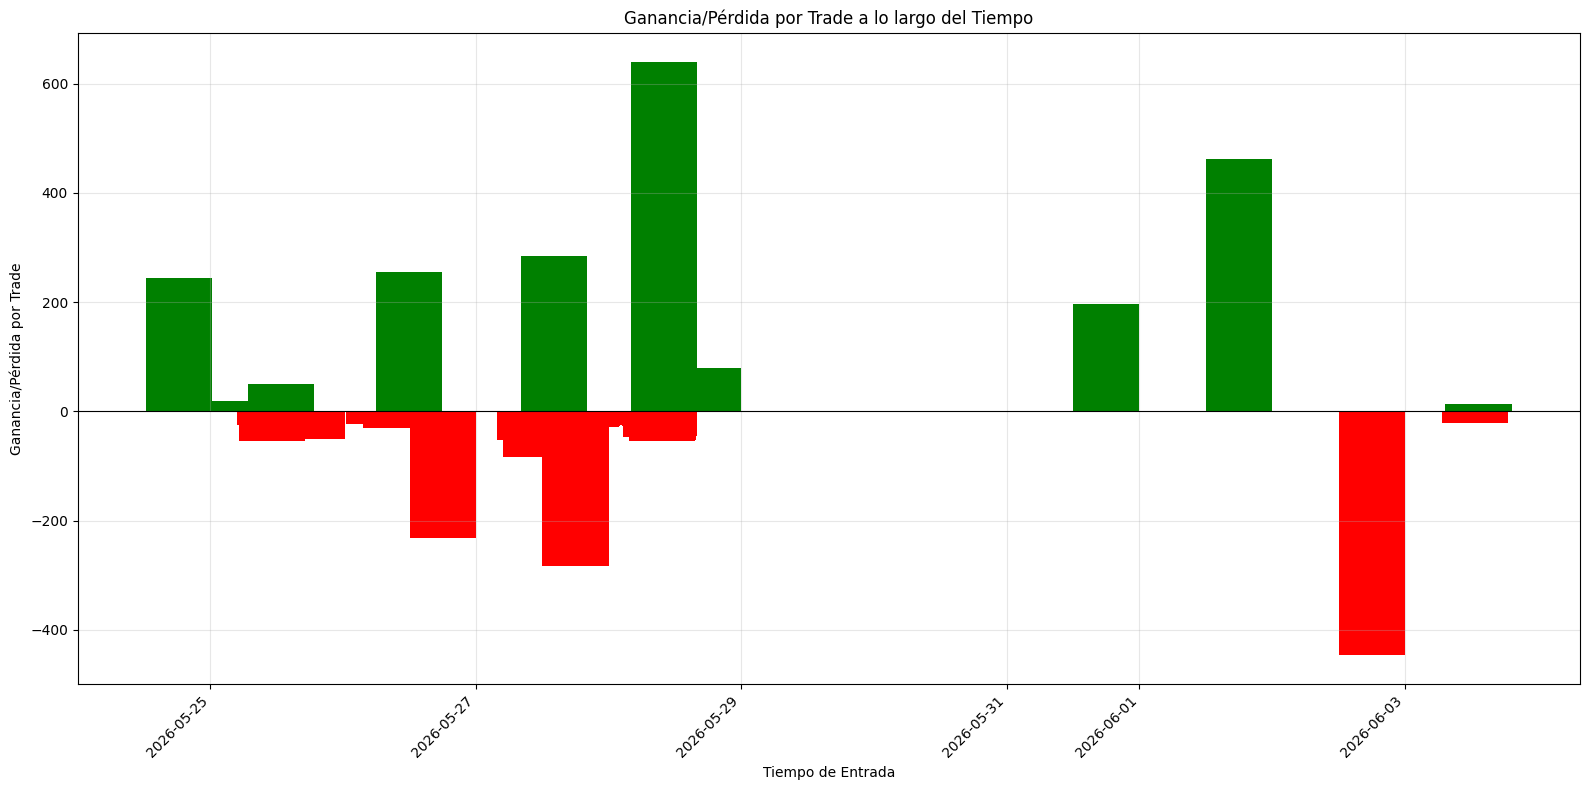

In [180]:
# Celda 11 — Genaración de Graáficas Profit Trades

import os
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 8))

ax.bar(
    df['Entry time'],
    df['Profit'],
    color=['green' if p > 0 else 'red' for p in df['Profit']], # Green for profit, red for loss
    width=0.5 # Adjust width as needed for better visualization, increased from 0.05
)

ax.set_title('Ganancia/Pérdida por Trade a lo largo del Tiempo')
ax.set_xlabel('Tiempo de Entrada')
ax.set_ylabel('Ganancia/Pérdida por Trade')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8) # Add a horizontal line at 0 for reference
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()

# Construct the full output path for the profit/loss per trade graph
output_path_profit = os.path.join(graph_output_directory, 'Profit_Loss_Per_Trade.jpg')

# Create the directory if it doesn't exist
os.makedirs(graph_output_directory, exist_ok=True)

# Save the figure before displaying it
fig.savefig(output_path_profit, bbox_inches='tight', dpi=300)
print(f'Gráfica Ganancia/Pérdida por Trade guardada en: {output_path_profit}')

plt.show()
plt.close(fig)

### Verificación del Directorio de Salida de Gráficas

El nombre del directorio de salida para las gráficas se construye dinámicamente como `bot_name` + `_` + `test_number`.

Por ejemplo, con `bot_name = 'RB01_MNQ_A'` y `test_number = 'T001'`, el directorio de salida de gráficas debería ser `RB01_MNQ_A_T001` dentro de la ruta base de gráficas.

Vamos a listar el contenido del directorio base de gráficas para confirmar qué carpetas existen actualmente.

In [181]:
# Celda 12 - Revisar contenido de la carpetas de graficas

import os

print(f"Listando el contenido de: {graph_output_base_path}")
if os.path.exists(graph_output_base_path):
    for item in os.listdir(graph_output_base_path):
        item_path = os.path.join(graph_output_base_path, item)
        if os.path.isdir(item_path):
            print(f"- Directorio: {item}")
        else:
            print(f"- Archivo: {item}")
else:
    print(f"Error: La ruta base de gráficas no existe: {graph_output_base_path}")

Listando el contenido de: /content/drive/MyDrive/Robots/Mis Bots/Datos Backtest/Graficas Backtest/
- Directorio: RB01_MNQ_A_T001


## Guardar el Notebook en GitHub (Opción 1: La más Sencilla)

La forma más directa de guardar **solo este notebook** en tu repositorio de GitHub es a través de la interfaz de Colab:

1.  Ve a `Archivo` en el menú superior.
2.  Selecciona `Guardar una copia en GitHub...`.
3.  Se abrirá una ventana donde podrás elegir tu repositorio, el nombre del archivo y el mensaje del commit.

Esto creará una copia del `.ipynb` en tu repositorio. Si quieres gestionar más archivos o tener un control más granular, la siguiente opción es para ti.

## Gestionar el Repositorio de GitHub desde Colab (Opción 2: Comandos `git`)

Para trabajar con un repositorio de Git completo (clonar, hacer cambios, `push`, `pull`, etc.) directamente desde Colab, puedes usar los comandos de `git` en las celdas de código.

**Consideraciones Importantes:**

*   **Autenticación**: Necesitarás un [Token de Acceso Personal (PAT) de GitHub](https://docs.github.com/es/authentication/keeping-your-account-and-data-secure/creating-a-personal-access-token) si tu repositorio es privado o si quieres empujar cambios a un repositorio público. Es más seguro que usar tu contraseña directamente.
*   **Google Drive**: La persistencia de tu repositorio (y los archivos generados) se mantendrá si trabajas dentro de tu Google Drive montado, ya que el sistema de archivos de Colab es efímero y se reinicia en cada sesión.

Sigue estos pasos:

### Paso 1: Instalar `gh` CLI (Opcional, pero útil para autenticación)

Aunque no es estrictamente necesario para `git`, el CLI de GitHub (`gh`) puede simplificar la autenticación. Si ya estás autenticado o prefieres usar solo `git`, puedes saltarte esta celda.

In [ ]:
# Instalar gh CLI
!pip install gh

# Autenticar (sigue las instrucciones en la consola)
# !gh auth login

### Paso 2: Navegar a tu directorio de trabajo en Google Drive

Asegúrate de que tu Google Drive esté montado (ya lo hiciste en la `Celda 2`). Luego, navega al directorio donde quieres tener tu repositorio de Git. Por ejemplo, si tu notebook está en `/content/drive/MyDrive/Colab Notebooks/`, deberías ir allí.

In [ ]:
# Cambia al directorio donde quieres que esté tu repositorio.
# Asegúrate de que esta ruta sea la carpeta que contiene tu notebook y otros archivos que quieres versionar.
# Por ejemplo:
# %cd /content/drive/MyDrive/Colab Notebooks/Backtests Colabs/

# Para este ejemplo, asumiremos que estás en la misma carpeta donde se guardan los datos/gráficas generadas.
# Usa la ruta base de tus robots o donde prefieras inicializar tu repo.
# Asegúrate de ajustar esta ruta a donde realmente quieras tu repositorio de Git.

repo_path = '/content/drive/MyDrive/Robots/Mis Bots/' # Esta es una sugerencia, AJUSTA SEGÚN TU ESTRUCTURA.

# Crea el directorio si no existe (aunque ya debería existir si guardas tus cosas allí)
!mkdir -p "{repo_path}"
%cd "{repo_path}"

!pwd # Verifica tu directorio actual

### Paso 3: Inicializar Git y Configurar tus credenciales

Si ya tienes un repositorio `git` clonado o inicializado en esta ubicación, puedes saltarte `git init`.

In [ ]:
# Inicializar un nuevo repositorio Git (si no lo has hecho ya)
!git init

# Configura tu nombre de usuario y correo electrónico de Git
!git config user.email "tu_email@example.com"  # ¡CAMBIA ESTO!
!git config user.name "Tu Nombre de Usuario GitHub" # ¡CAMBIA ESTO!

### Paso 4: Añadir y hacer commit de tus cambios

Aquí es donde añades el notebook actual (`.ipynb`) y cualquier otro archivo que quieras versionar.

In [ ]:
# Añade todos los archivos modificados o nuevos al área de staging
!git add .

# Haz un commit de los cambios
# Cambia el mensaje del commit por uno descriptivo.
!git commit -m "Actualización de Colab: Limpieza de datos y generación de gráficas"

### Paso 5: Añadir el repositorio remoto y empujar (push)

Si es la primera vez que empujas a un repositorio remoto, necesitarás añadirlo. Si ya lo has configurado antes (por ejemplo, si clonaste el repo), puedes saltarte `git remote add origin`.

In [ ]:
# Asegúrate de que tu repositorio remoto esté configurado.
# Si no lo está, añádelo (reemplaza <URL_DEL_REPOSITORIO> con la URL de tu repo en GitHub)
# Por ejemplo: https://github.com/tu_usuario/tu_repositorio.git
# !git remote add origin https://github.com/tu_usuario/tu_repositorio.git

# Si ya está añadido, puedes verificarlo con:
!git remote -v

# Empuja tus cambios al repositorio remoto
# La primera vez, usa -u para establecer el seguimiento de la rama (main o master).
!git push -u origin main

# Si te pide credenciales, ingresa tu nombre de usuario de GitHub y tu Personal Access Token (PAT) como contraseña.

Después de seguir estos pasos, tus cambios (incluyendo el notebook y otros archivos añadidos) deberían estar en tu repositorio de GitHub. ¡No olvides ajustar las rutas y las credenciales según tu configuración!